In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from utils import plot_hist_per_year, get_season, calculate_seasonal_factors, calculate_weekday_season_factors, get_season_year

# Description

In this notebook, we will perform the descriptive analysis outlined in Team Assignment 2-a. Before analyzing patterns across different time scales (days, weeks, and seasons), we will first take a brief look at the dataset to understand if, for example, there are multiple seasons represented.

#### Tasks
- [ ] Analyze seasonal patterns
- [ ] Analyze weekly patterns
- [ ] Analyze daily patterns

In [2]:
full_charging_df = pd.read_feather("../data/full_charging_data.feather")
full_charging_df

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,...,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,connectionTimespan,doneDisconnectTimespan,connectionMonth,connectionWeekdayName,connectionYear,isWeekend
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,...,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00,0 days 06:02:21,0 days 01:39:40,1,Thursday,2020,False
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,...,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00,0 days 09:01:31,0 days 02:20:16,1,Thursday,2020,False
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,...,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00,0 days 10:42:47,0 days 08:04:16,1,Thursday,2020,False
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,...,65.0,2020-01-02 06:00:19-08:00,True,2020-01-02 07:04:58-08:00,0 days 02:38:41,0 days 01:19:54,1,Thursday,2020,False
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,...,504.0,2020-01-02 06:00:13-08:00,True,2020-01-02 14:24:01-08:00,0 days 08:08:39,0 days 03:51:10,1,Thursday,2020,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65032,5d2fbdd3f9af8b4d0dd0d54a,2019-07-01 14:49:12-07:00,2019-07-01 18:37:18-07:00,2019-07-01 16:14:33-07:00,8.399,1_1_179_798_2019-07-01 21:49:11.873404,1,AG-3F18,1-1-179-798,America/Los_Angeles,...,36.0,2019-07-01 14:51:07-07:00,True,2019-07-01 15:25:12-07:00,0 days 03:48:06,0 days 02:22:45,7,Monday,2019,False
65033,5d2fbdd3f9af8b4d0dd0d54b,2019-07-01 14:58:45-07:00,2019-07-01 17:39:48-07:00,2019-07-01 17:40:21-07:00,16.864,1_1_179_794_2019-07-01 21:58:44.571011,1,AG-3F20,1-1-179-794,America/Los_Angeles,...,234.0,2019-07-01 14:59:09-07:00,True,2019-07-01 18:52:45-07:00,0 days 02:41:03,-1 days +23:59:27,7,Monday,2019,False
65034,5d2fbdd3f9af8b4d0dd0d54c,2019-07-01 15:02:21-07:00,2019-07-01 17:58:50-07:00,2019-07-01 17:59:23-07:00,18.335,1_1_191_807_2019-07-01 22:02:20.810735,1,AG-4F47,1-1-191-807,America/Los_Angeles,...,192.0,2019-07-01 15:03:30-07:00,True,2019-07-01 18:14:21-07:00,0 days 02:56:29,-1 days +23:59:27,7,Monday,2019,False
65035,5d2fbdd3f9af8b4d0dd0d54d,2019-07-01 15:23:44-07:00,2019-07-01 19:03:36-07:00,2019-07-01 19:04:06-07:00,22.815,1_1_179_781_2019-07-01 22:23:32.496137,1,AG-3F31,1-1-179-781,America/Los_Angeles,...,99.0,2019-07-01 15:23:43-07:00,True,2019-07-01 17:02:44-07:00,0 days 03:39:52,-1 days +23:59:30,7,Monday,2019,False


### Seasonal Patterns

When talking about seasonal patterns it is important to also understand why one wants to talk about them. The calendaric seasons are well suited for comparing different seasons if it is important that they have all equivilant timespans but when one wants to talk about seasons because one wants to know what people behave when its warm (Summerlike) or cold (winterlike) the meteorological seasons may can be used to create more informative insights. As it is not specified which one should be done in this tasks (and also because this may also is important for the predection model task we first will use the calendar seasons to describe the data and afterwards the meteorologial once in Burbank. For this the following data is used:

https://www.timeanddate.com/calendar/seasons.html?year=2000&n=796 / burbank_seasons.feather

In [3]:
burbank_seasons = pd.read_feather("../data/burbank_seasons.feather")
burbank_seasons

,Year,Spring Start,Summer Start,Autumn Start,Winter Start
0,2018,2018-03-20 02:15:00-07:00,2018-06-20 20:07:00-07:00,2018-09-22 11:54:00-07:00,2018-12-21 06:22:00-08:00
1,2019,2019-03-20 07:58:00-07:00,2019-06-21 01:54:00-07:00,2019-09-22 17:50:00-07:00,2019-12-21 12:19:00-08:00
2,2020,2020-03-19 13:49:00-07:00,2020-06-20 07:43:00-07:00,2020-09-21 23:30:00-07:00,2020-12-20 18:02:00-08:00
3,2021,2021-03-19 19:37:00-07:00,2021-06-20 13:32:00-07:00,2021-09-22 05:21:00-07:00,2021-12-20 23:59:00-08:00
4,2022,2022-03-20 01:33:00-07:00,2022-06-20 19:13:00-07:00,2022-09-22 11:03:00-07:00,2022-12-21 05:48:00-08:00


In [4]:
# for the original csv file
# time_columns = burbank_seasons.columns.drop("Year")
# burbank_seasons[time_columns] = burbank_seasons[time_columns].apply(
#     lambda x: pd.to_datetime(x, utc=True))
# # Transform the timestamps from UTC to the correct timezone
# burbank_seasons[time_columns] = burbank_seasons[time_columns].apply(
#     lambda col: col.dt.tz_convert("America/Los_Angeles"))
# burbank_seasons.to_feather("../data/burbank_seasons.feather")

Here we add the season_year and the season to the full_charging_df to be able to analyze the seasonal patterns.
The Season Year differs from the connection year as it adds the winter of the end of a calendaric year to the next year. This is important as the winter is the only season which is split between two years. 

The season is calculated based on the connectionTime.

In [4]:
full_charging_df["season_year"] = full_charging_df["connectionTime"].apply(get_season_year)
full_charging_df["season"] = full_charging_df["connectionTime"].apply(get_season)

In [5]:
full_charging_df["connectionYear"].value_counts().sort_index()

connectionYear
2018    20067
2019    28019
2020     8041
2021     8910
Name: count, dtype: int64

In [7]:
full_charging_df["season_year"].value_counts().sort_index()

season_year
2018    19828
2019    27893
2020     8279
2021     9037
Name: count, dtype: int64

As we can see here the shift in the winter season is visible in the data. As 2018 looses some records due to the missing data prior as well as the convertion of (some of the) the december connections to 2019.


In [8]:
# just an example
example_year = 2020
full_charging_df[(full_charging_df['connectionYear'] == example_year) & (full_charging_df['season_year'] == example_year + 1)][["connectionTime"]]

,connectionTime
5507,2020-12-21 06:20:09-08:00
5508,2020-12-21 06:21:50-08:00
5509,2020-12-21 06:55:11-08:00
5510,2020-12-21 07:45:11-08:00
5511,2020-12-21 08:07:52-08:00
...,...
51582,2020-12-30 14:09:41-08:00
51583,2020-12-30 15:02:11-08:00
51584,2020-12-31 08:17:43-08:00
51585,2020-12-31 08:45:14-08:00


In [9]:
full_charging_df["season"].value_counts()

season
Summer    18848
Autumn    16874
Spring    14834
Winter    14481
Name: count, dtype: int64

#### Explanation
Across all seasons, we can observe that most records occur in the summer. However, since our data is incomplete for all seasons, we cannot definitively conclude whether this is due to the data limitations or the actual behavior of the people. Therefore, we need to review the data for the different years to determine if it is complete for all seasons.
Additionally, the seasonal figures are a useful measure for identifying seasonal patterns in the data. Since we have a lower number of records for 2021, the multiplicative seasonal figures are used, as this may be due to an overall change in behavior rather than a shift in seasonal patterns.

In [10]:
years = sorted(full_charging_df["connectionYear"].unique())
years

[np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]

In [11]:
for year in years:
    print(year, full_charging_df[full_charging_df["season_year"] == year]["season"].value_counts())

2018 season
Autumn    9236
Summer    7311
Spring    3281
Name: count, dtype: int64
2019 season
Spring    7617
Summer    6990
Autumn    6975
Winter    6311
Name: count, dtype: int64
2020 season
Winter    6056
Spring     845
Summer     715
Autumn     663
Name: count, dtype: int64
2021 season
Summer    3832
Spring    3091
Winter    2114
Name: count, dtype: int64


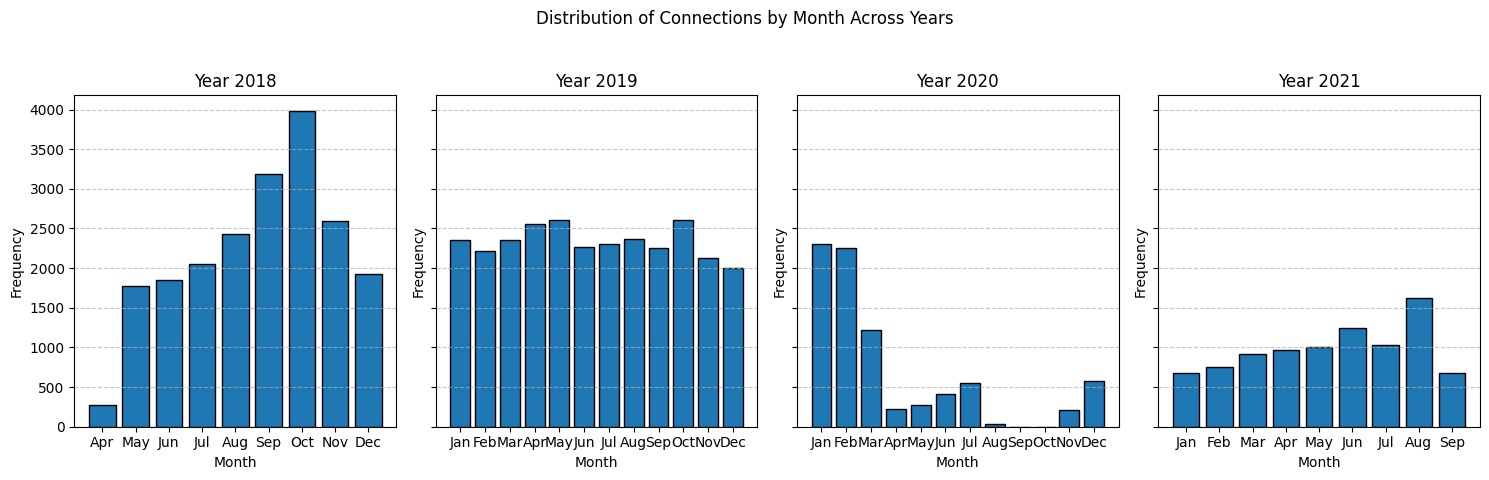

In [12]:
# Just a reminder
plot_hist_per_year(df=full_charging_df, title="Distribution of Connections by Month Across Years")

#### Explanation
When visually validating the results (counts) we got for the seasons we see that the lack of rows in winter 2018 or the missing autumn 2021 are also visibale in the data. Also as every season is differerently we need to evaluate the seasonal patterns based on the seasons themself. 2019 can be used as "default" here because this is the only year where we have collected counts for the whole year and also have no disruptive event as corona. 

##### Ideas
- for 2020 we may be able to build a regression model which has corona has parameter thus enables us to forcast how this year could have looked like without covid 19 but i am no sure.
- **maybe do the same analysis also for the seasons as they are in the calendar**

In [13]:
saisonfiguren_list = []
for year in sorted(full_charging_df["connectionYear"].unique()):
    saisonfiguren_list.append(calculate_seasonal_factors(full_charging_df[full_charging_df["season_year"] == year] , year))

saisonfiguren = pd.concat(saisonfiguren_list)
saisonfiguren = saisonfiguren.sort_values(['year', 'season']).reset_index(drop=True)
saisonfiguren

,year,season,record_count,seasonal_factor
0,2018,Spring,3281,0.496419
1,2018,Summer,7311,1.106163
2,2018,Autumn,9236,1.397418
3,2019,Winter,6311,0.905030
4,2019,Spring,7617,1.092317
5,2019,Summer,6990,1.002402
6,2019,Autumn,6975,1.000251
7,2020,Winter,6056,2.925957
8,2020,Spring,845,0.408262
9,2020,Summer,715,0.345452


#### Overall

Summer consistently seems to be a season when the stations are used more frequently (except in 2020). In contrast, winter tends to be a season with lower usage. Spring and autumn fall somewhere in between (considering that 2018 is a special case).

##### Explanation

This data tells a specific story. First of all, in Spring 2018, we started our program (most likely; at least we began measuring). At that time, the service was quite new and needed to gain momentum. Subsequently, the summer and following autumn saw quite a few records, but this was mainly due to growth and not just the seasonal pattern. Most likely, we would need a regression model that accounts for the seasonal pattern in order to calculate the residuals for 2018, which would reflect the popularity of the service (at least, this seems to be the approach). In 2019, the service became established, and the seasonal pattern became visible. Although residuals are still present, they are not as significant as in 2018 or 2020. In 2020, the coronavirus pandemic hit, and the service was used less than in previous years. Additionally, our lack of data from August to November of this year makes the seasonal patterns quite unreliable. In 2021, the service usage increased again, and in the winter, it appears that the service recovered from the downturn earlier.

### Weeks

In [14]:
df = full_charging_df[full_charging_df["connectionYear"] == 2019]
df["connectionWeekdayName"].value_counts()

connectionWeekdayName
Tuesday      5686
Wednesday    5595
Thursday     5437
Monday       5287
Friday       4432
Saturday      874
Sunday        708
Name: count, dtype: int64

In [15]:
weekday_factor_list = []
for year in years:
    weekday_factors = calculate_weekday_season_factors(full_charging_df[full_charging_df["connectionYear"] == year], "connectionWeekdayName", year)
    weekday_factor_list.append(weekday_factors)
weekday_factors = pd.concat(weekday_factor_list)
weekday_factors.sort_values(['year', 'weekday']).reset_index(drop=True)

,weekday,record_count,seasonal_factor,year
0,Monday,3380,1.179050,2018
1,Tuesday,3498,1.220212,2018
2,Wednesday,3492,1.218119,2018
3,Thursday,3548,1.237654,2018
4,Friday,3294,1.149051,2018
5,Saturday,1442,0.503015,2018
6,Sunday,1413,0.492899,2018
7,Monday,5287,1.320854,2019
8,Tuesday,5686,1.420536,2019
9,Wednesday,5595,1.397801,2019


In [16]:
# For all years
weekday_factors.drop(['year'], axis=1).groupby('weekday').mean()

/var/folders/ft/321k4kxs5r9cs1cshjn4m3rh0000gn/T/ipykernel_81476/103845545.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekday_factors.drop(['year'], axis=1).groupby('weekday').mean()


,record_count,seasonal_factor
weekday,,
Monday,2942.00,1.266409
Tuesday,3149.00,1.365377
Wednesday,3115.00,1.349834
Thursday,3069.25,1.329768
Friday,2560.75,1.084713
Saturday,748.75,0.319031
Sunday,674.50,0.284869


## Daily Patterns

In [6]:
# Needs to be in data_preparation,ipynb
full_charging_df['connectionHour'] = full_charging_df['connectionTime'].dt.hour
full_charging_df['disconnectHour'] = full_charging_df['disconnectTime'].dt.hour
full_charging_df['doneChargingHour'] = full_charging_df['doneChargingTime'].dt.hour
full_charging_df['loading_duration'] = (
        (full_charging_df['doneChargingTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
)
full_charging_df['connected_duration'] = (
        (full_charging_df['disconnectTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
)
full_charging_df['ratio_loading_to_connected'] = (
        full_charging_df['loading_duration'] / full_charging_df['connected_duration']
)

#### Average number of new connections per hour

##### What is shown?
This chart shows the average number of **new connections (charges)** per hour throughout the day.

##### Results
- Most new connections occur between **6:00 and 8:00**, indicating a high arrival rate in the early morning hours.
- A small increase can be observed at **12:00**, which may be related to the lunch break.


#### Average number of connections per hour

##### What is shown?
This chart shows the average number of **connections** per hour, regardless of whether a vehicle is actually charging or just connected.

##### Results
- The total number of connections is highest during the day between **07:00 and 18:00**, which corresponds to a typical working day




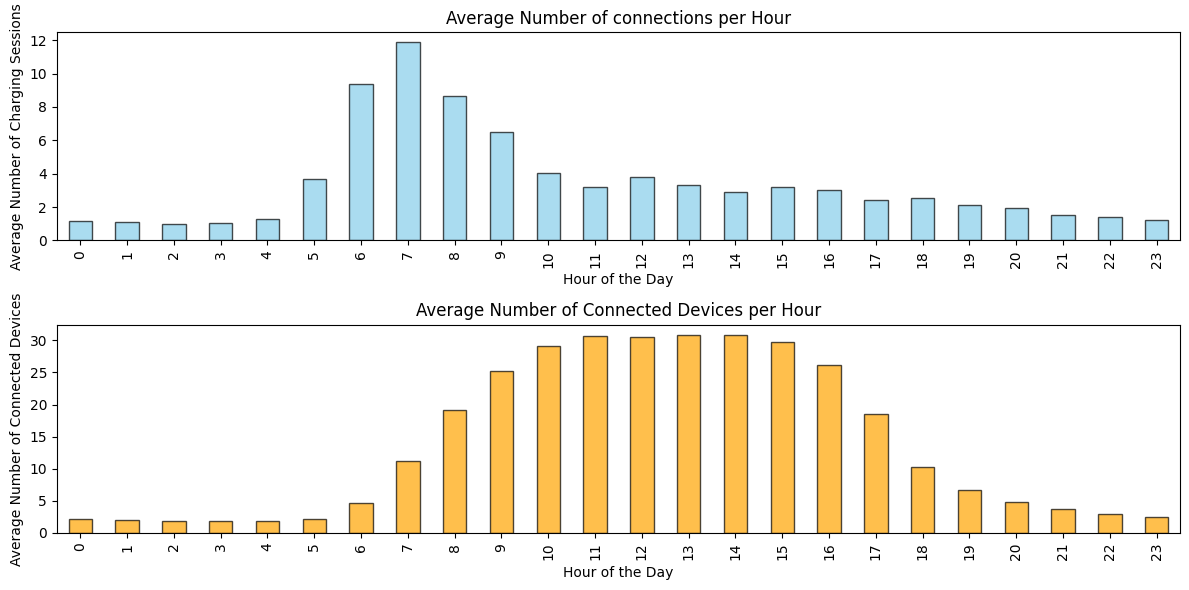

In [12]:
# Convert to Datetime format
full_charging_df['connectionTime'] = pd.to_datetime(full_charging_df['connectionTime'])
full_charging_df['disconnectTime'] = pd.to_datetime(full_charging_df['disconnectTime'])

# Extract date and hour
full_charging_df['date'] = full_charging_df['connectionTime'].dt.date
full_charging_df['connectionHour'] = full_charging_df['connectionTime'].dt.hour

# Count the number of charging sessions per hour
hourly_starts = full_charging_df.groupby(['date', 'connectionHour']).size().reset_index(name='count')

# Compute the average number of started charging sessions per hour
hourly_starts_avg = hourly_starts.groupby('connectionHour')['count'].mean()

# Generate a list of all hourly timestamps in the dataset
all_hours = pd.date_range(
    start=full_charging_df['connectionTime'].min(),
    end=full_charging_df['disconnectTime'].max(),
    freq='h'
)

connected_devices = []

# Count the number of connected devices per hour (per day)
for hour in all_hours:
    count = ((full_charging_df['connectionTime'] <= hour) & (full_charging_df['disconnectTime'] >= hour)).sum()
    connected_devices.append({'date': hour.date(), 'hour': hour.hour, 'connected_count': count})

# Create a DataFrame for connected devices
connected_devices_df = pd.DataFrame(connected_devices)

# Compute the average number of connected devices per hour
hourly_connected_avg = connected_devices_df.groupby('hour')['connected_count'].mean()

# Visualization
plt.figure(figsize=(12, 6))

# Chart 1
plt.subplot(2, 1, 1)
hourly_starts_avg.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Average Number of connections per Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Number of Charging Sessions')

# Chart 2
plt.subplot(2, 1, 2)
hourly_connected_avg.plot(kind='bar', color='orange', edgecolor='black', alpha=0.7)
plt.title('Average Number of Connected Devices per Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Number of Connected Devices')

plt.tight_layout()
plt.show()


Displaying the results in a table


In [8]:
# Ensure all 24 hours are included, filling missing values with 0
hourly_starts_avg_df = hourly_starts_avg.reindex(range(24), fill_value=0)
hourly_connected_avg_df = hourly_connected_avg.reindex(range(24), fill_value=0)

# Create a table with results
hourly_analysis_df = pd.DataFrame({
    'Hour': range(24),
    'Started Charging Sessions': hourly_starts_avg_df,
    'Connected Devices': hourly_connected_avg_df
})

# Format hour representation
hourly_analysis_df['Hour'] = hourly_analysis_df['Hour'].astype(str).str.zfill(2) + ':00'

hourly_analysis_df = hourly_analysis_df.set_index('Hour')

# Output table
print(hourly_analysis_df)


       Started Charging Sessions  Connected Devices
Hour                                               
00:00                   1.173228           2.174475
01:00                   1.088608           1.950846
02:00                   1.014085           1.825911
03:00                   1.050000           1.800485
04:00                   1.301493           1.842615
05:00                   3.671449           2.238902
06:00                   9.404028           4.626312
07:00                  11.878755          11.258273
08:00                   8.639745          19.210016
09:00                   6.506250          25.226979
10:00                   4.013684          29.144588
11:00                   3.209730          30.617124
12:00                   3.781381          30.482229
13:00                   3.330803          30.864297
14:00                   2.894796          30.866721
15:00                   3.194743          29.779483
16:00                   3.030000          26.190630
17:00       

#### End Time of Charging Sessions (Vehicle Disconnection Time)
##### What is shown?
This diagram displays the time at which most vehicles **disconnect** from the charging station, indicating when the station is freed up.

##### Results
- Vehicles start **disconnecting from 3:00 PM onwards**, suggesting that some users leave earlier or have shorter charging sessions.
- The **peak disconnection time is around 5:00 PM**, indicating that most users finish their workday or university schedule at this time.
- After **6:00 PM, the number of disconnections drops significantly**, meaning that most vehicles have already left


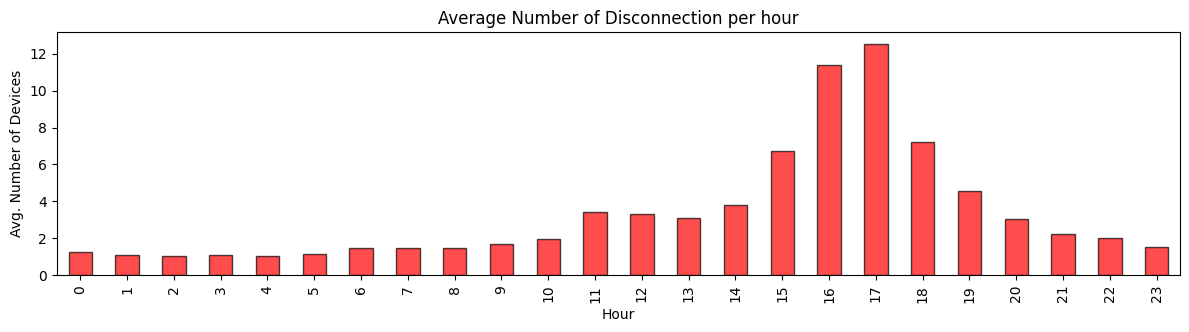

In [13]:
# Number of devices
hourly_disconnects = full_charging_df.groupby(['date', 'disconnectHour']).size().reset_index(name='count')

hourly_done = full_charging_df.groupby(['date', 'doneChargingHour']).size().reset_index(name='count')

# Average per hour across all days
hourly_disconnects_avg = hourly_disconnects.groupby('disconnectHour')['count'].mean()
hourly_done_avg = hourly_done.groupby('doneChargingHour')['count'].mean()

# Ensure all 24 hours are included, fill missing values with 0
hourly_disconnects_avg = hourly_disconnects_avg.reindex(range(24), fill_value=0)
hourly_done_avg = hourly_done_avg.reindex(range(24), fill_value=0)

# Visualization
plt.figure(figsize=(12, 6))

# Chart 1
plt.subplot(2, 1, 1)
hourly_disconnects_avg.plot(kind='bar', color='red', edgecolor='black', alpha=0.7)
plt.title('Average Number of Disconnection per hour')
plt.xlabel('Hour')
plt.ylabel('Avg. Number of Devices')


plt.tight_layout()
plt.show()


#### Average Charging and Connection Duration per Connection Hour

##### What is shown?
Bar chart showing **average charging duration (blue)** and **total connection duration (brown)** per hour.

###### Results
- Morning hours (2 AM - 7 AM) have the longest charging durations, suggesting overnight charging.
- Total connection duration remains high throughout the day, indicating vehicles stay connected after charging ends.
- Shorter durations in the afternoon suggest quick charging sessions, while evening connections likely last overnight.


<Figure size 1200x600 with 0 Axes>

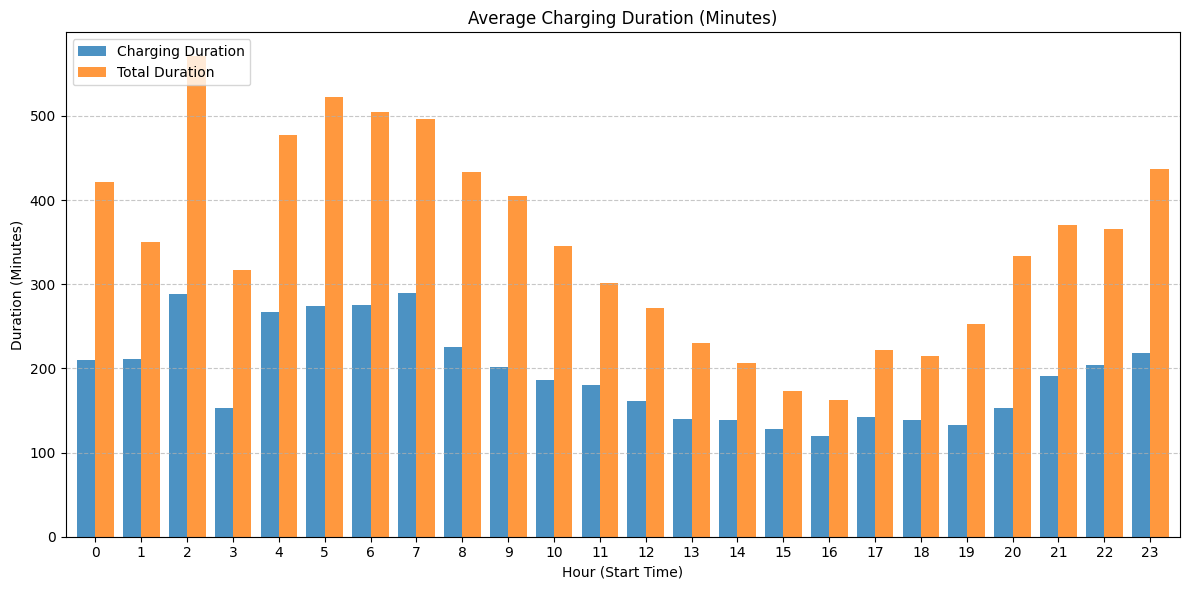

In [16]:
# Avg duration per connection hour
hourly_durations = full_charging_df.groupby('connectionHour').agg({
    'loading_duration': 'mean',
    'connected_duration': 'mean'
}).reindex(range(24), fill_value=0)

# Visualization
plt.figure(figsize=(12, 6))

hourly_durations.plot(kind='bar', figsize=(12, 6), width=0.8, alpha=0.8)
plt.title('Average Charging Duration (Minutes)')
plt.xlabel('Hour (Start Time)')
plt.ylabel('Duration (Minutes)')
plt.legend(['Charging Duration', 'Total Duration'], loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


#### Ratio of Charging Duration to Total Duration per Hour

##### What is shown?
- Line chart displaying the **average ratio of charging time to total connection time** per hour.
- Indicates how efficiently charging stations are used at different times of the day.

##### Results
- Lowest ratios occur in early morning hours (0-9 AM), meaning vehicles stay connected long after charging ends.
- Highest ratios between 3 PM - 5 PM, indicating that users disconnect shortly after charging is complete.


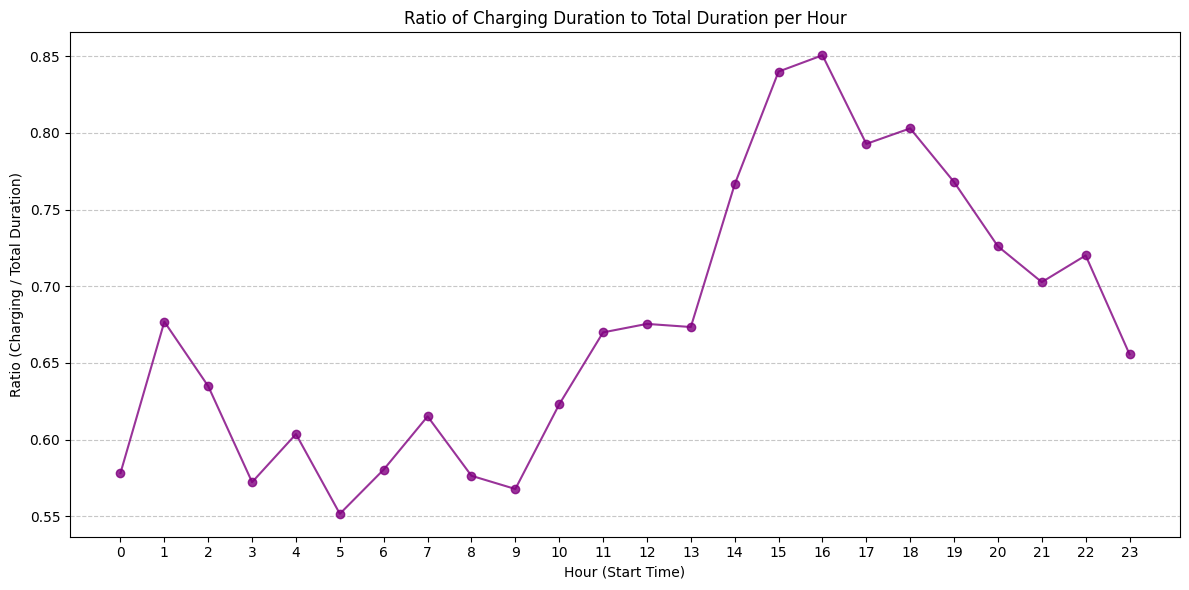

In [17]:
# Avg ratio of charging duration to total connected duration /h
hourly_ratios = full_charging_df.groupby('connectionHour')['ratio_loading_to_connected'].mean().reindex(range(24), fill_value=0)

# Visualization
plt.figure(figsize=(12, 6))
hourly_ratios.plot(kind='line', marker='o', color='purple', alpha=0.8)
plt.title('Ratio of Charging Duration to Total Duration per Hour')
plt.xlabel('Hour (Start Time)')
plt.ylabel('Ratio (Charging / Total Duration)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(24))
plt.tight_layout()
plt.show()



#### Average Charging vs. Connected-Only Devices per Hour

##### What is shown?
- Bar chart comparing the **average number of actively charging vehicles** (blue) vs. **vehicles that are only connected** (orange) per hour.
- Highlights the difference between energy consumption and station occupancy.

##### Results
- Peak charging activity occurs between 8 AM - 11 AM, aligning with morning arrivals.
- After 12 PM, the number of connected-but-not-charging vehicles surpasses actively charging ones, indicating prolonged station occupancy without energy consumption.



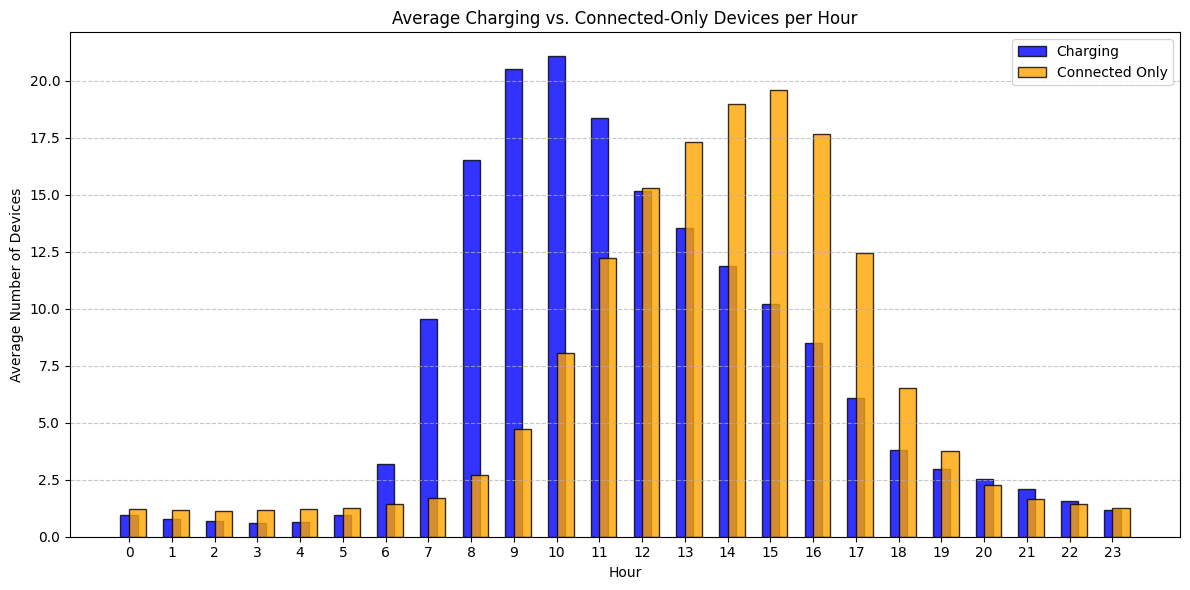

In [18]:
all_hours = pd.date_range(
    start=full_charging_df['connectionTime'].min(),
    end=full_charging_df['disconnectTime'].max(),
    freq='h'
)

active_loading = []
just_connected = []

# calculate indicators
for hour in all_hours:
    current_date = hour.date()
    current_hour = hour.hour

    # Actively charging devices
    loading_count = ((full_charging_df['connectionTime'] <= hour) &
                     (full_charging_df['doneChargingTime'] >= hour)).sum()

    # Connected but not charging devices
    connected_count = ((full_charging_df['connectionTime'] <= hour) &
                       (full_charging_df['disconnectTime'] >= hour)).sum()

    not_loading_count = connected_count - loading_count

    # results
    active_loading.append({'date': current_date, 'hour': current_hour, 'count': loading_count})
    just_connected.append({'date': current_date, 'hour': current_hour, 'count': not_loading_count})

# df
active_loading_df = pd.DataFrame(active_loading)
just_connected_df = pd.DataFrame(just_connected)

active_loading_avg = active_loading_df.groupby('hour')['count'].mean()
just_connected_avg = just_connected_df.groupby('hour')['count'].mean()

active_loading_avg = active_loading_avg.reindex(range(24), fill_value=0)
just_connected_avg = just_connected_avg.reindex(range(24), fill_value=0)

# Visualization
plt.figure(figsize=(12, 6))

x = range(24)
plt.bar(x, active_loading_avg, width=0.4, label='Charging', align='center', alpha=0.8, color='blue', edgecolor='black')
plt.bar(x, just_connected_avg, width=0.4, label='Connected Only', align='edge', alpha=0.8, color='orange', edgecolor='black')

plt.title('Average Charging vs. Connected-Only Devices per Hour')
plt.xlabel('Hour')
plt.ylabel('Average Number of Devices')
plt.xticks(range(24))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()